### This notebook contains results and visualizations for VQVAE training.

In [1]:
# exp/ → project_root/
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from data.dataset import get_cifar_10_dataset
from models.vqvae import VQVAE

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [12]:
# load model
model = VQVAE().to(device)
model.load_state_dict(torch.load('../checkpoints/vqvae.pth', map_location=device))
model.eval()

VQVAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (codebook): Codebook(
    (codebook): Embedding(512, 256)
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
      (1): ReLU()
      (2): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): ConvTranspose2d(128, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): Tanh()
    )
  )
)

In [3]:
# load new model
new_model = VQVAE().to(device)
new_model.load_state_dict(torch.load('../checkpoints/vqvae.pth', map_location=device))
new_model.eval()

VQVAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (codebook): Codebook(
    (codebook): Embedding(512, 256)
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
      (1): ReLU()
      (2): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): ConvTranspose2d(128, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): Tanh()
    )
  )
)

In [4]:
# load dataset

train_loader, _ = get_cifar_10_dataset(batch_size=64)
batch, labels   = next(iter(train_loader))
batch           = batch.to(device)

In [15]:
# try model eval on a batch of images
with torch.no_grad():
    x_recon, total_loss, recon_loss, codebook_loss, commitment_loss, indices = model(batch)

print(f"total loss: {total_loss.item():.4f}")
print(f"reconstruction loss: {recon_loss.item():.4f}")
print(f"codebook loss: {codebook_loss.item():.4f}")
print(f"commitment loss: {commitment_loss.item():.4f}")
print(f"indices shape: {indices.shape}")       # (64, 8, 8)
print(f"indices range: {indices.min()} - {indices.max()}")

total loss: 0.1220
reconstruction loss: 0.0249
codebook loss: 0.0777
commitment loss: 0.0777
indices shape: torch.Size([64, 8, 8])
indices range: 5 - 503


In [5]:
# try new model eval on a batch of images
with torch.no_grad():
    x_recon, total_loss, recon_loss, codebook_loss, commitment_loss, indices = new_model(batch)

print(f"total loss: {total_loss.item():.4f}")
print(f"reconstruction loss: {recon_loss.item():.4f}")
print(f"codebook loss: {codebook_loss.item():.4f}")
print(f"commitment loss: {commitment_loss.item():.4f}")
print(f"indices shape: {indices.shape}")       # (64, 8, 8)
print(f"indices range: {indices.min()} - {indices.max()}")

total loss: 0.1286
reconstruction loss: 0.0248
codebook loss: 0.0831
commitment loss: 0.0831
indices shape: torch.Size([64, 8, 8])
indices range: 5 - 503


### Codebook indicies usage 

In [6]:
# take a batch size of 20 and check what the indices are being utilized for quantization by the codebook

all_indices = []
new_all_indices = []

with torch.no_grad():
    for i, (batch, _) in enumerate(train_loader):
        if i >= 20: break  
        #_, _, _, _, _, indices = model(batch.to(device)) # indices of shape (64, 8, 8)
        _, _, _, _, _, new_indices = new_model(batch.to(device)) # indices of shape (64, 8, 8)
        #all_indices.append(indices.cpu().flatten())  #flattened shape: (4096,)
        new_all_indices.append(new_indices.cpu().flatten())  #flattened shape: (4096,)

In [7]:
# 20 batches of indices used each batch of 64 images for quantization
print(f"Total indices collected: {len(new_all_indices) * new_all_indices[0].shape[0]}")  # 20 batches * 4096 indices per batch of 64 images

Total indices collected: 81920


In [8]:
#concatenate and check the index usage
#all_indices = torch.cat(all_indices)
new_all_indices = torch.cat(new_all_indices)

In [30]:
print(all_indices.shape)  # should be (81920,) for 20 batches of 64 images with 8x8 indices

# count how often each codebook entry was used
counts = torch.bincount(all_indices, minlength=512).float()
usage  = (counts > 0).sum().item()
print(f"codebook utilization: {usage}/512 entries used ({100*usage/512:.1f}%)")

torch.Size([81920])
codebook utilization: 53/512 entries used (10.4%)


In [9]:
counts_new = torch.bincount(new_all_indices, minlength=512).float()
new_usage  = (counts_new > 0).sum().item()
print(f"new codebook utilization: {new_usage}/512 entries used ({100*new_usage/512:.1f}%)")

new codebook utilization: 53/512 entries used (10.4%)


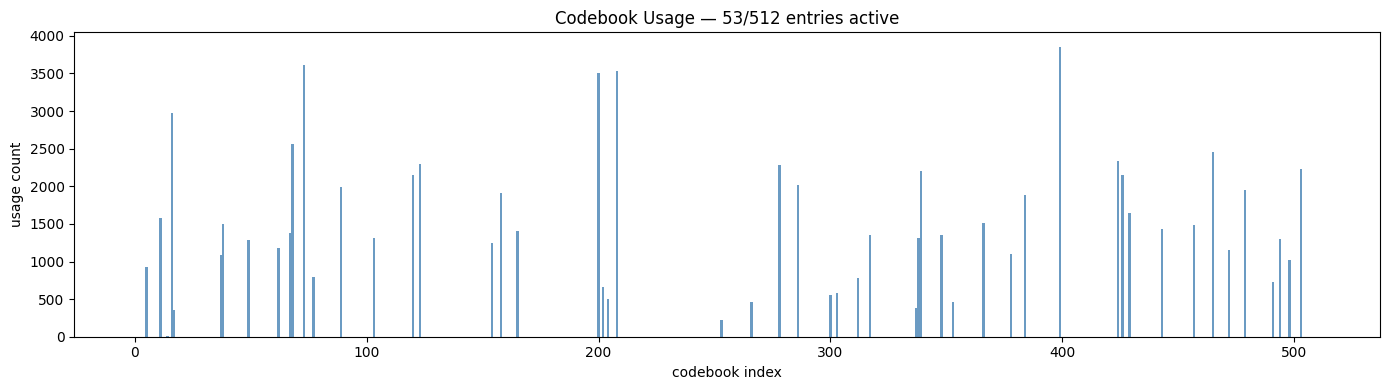

In [ ]:
plt.figure(figsize=(14, 4))
plt.bar(range(512), counts.numpy(), width=1.0, color='steelblue', alpha=0.8)
plt.xlabel('codebook index')
plt.ylabel('usage count')
plt.title(f'Codebook Usage — {usage}/512 entries active')
plt.tight_layout()

#observation: very less embedding space is being utilized, might have to rerun and check it the results stay the same and lower the num_embeddings later

### check codebook usage on new model

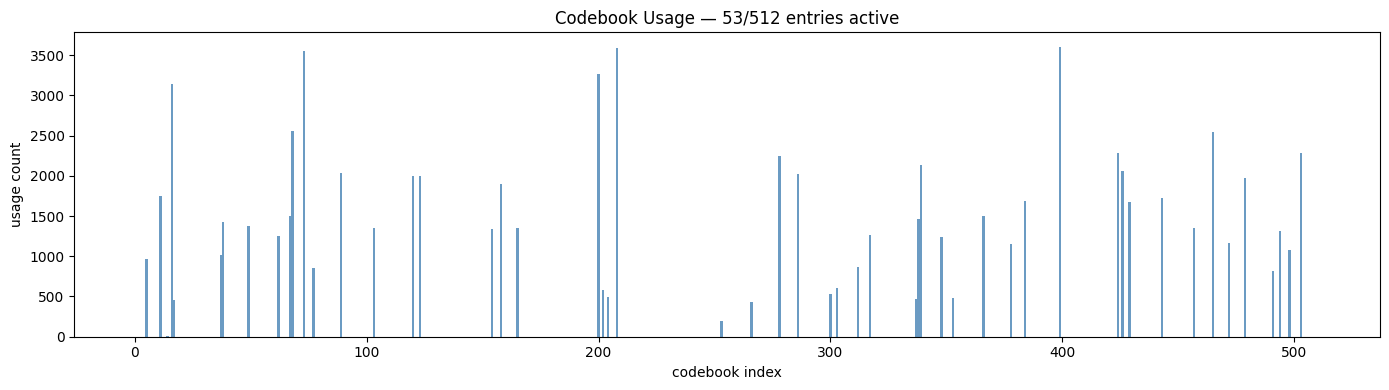

In [11]:
plt.figure(figsize=(14, 4))
plt.bar(range(512), counts_new.numpy(), width=1.0, color='steelblue', alpha=0.8)
plt.xlabel('codebook index')
plt.ylabel('usage count')
plt.title(f'Codebook Usage — {new_usage}/512 entries active')
plt.tight_layout()

### Visualizing the token grid (this is what the transformer will see)

In [33]:
def denormalize(x):
    return (x * 0.5 + 0.5).clamp(0, 1)

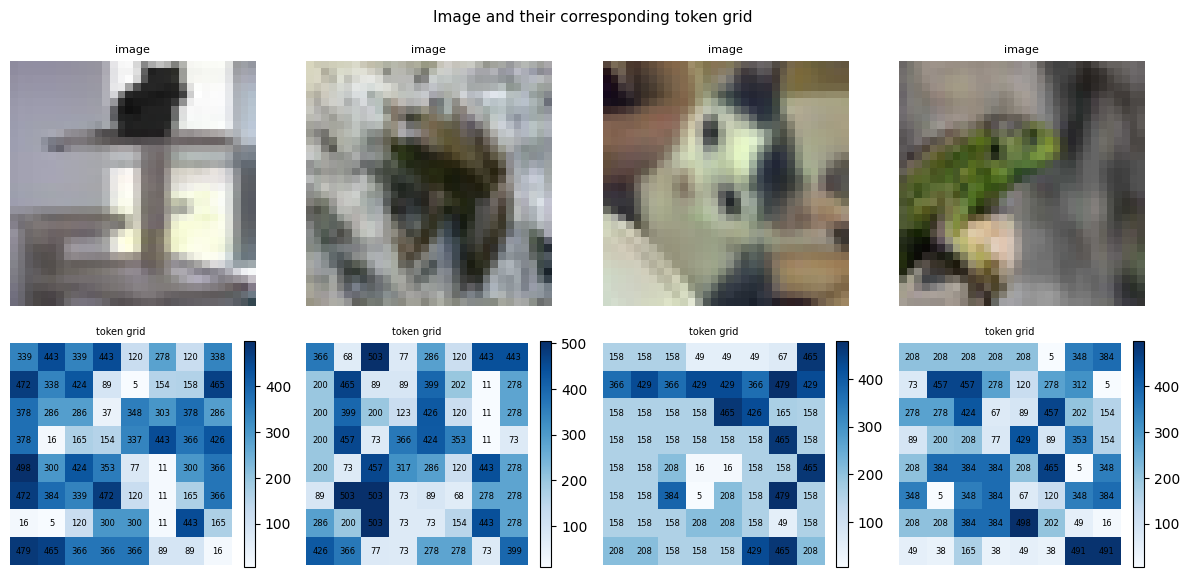

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):  # take 4 images from the batch and visualize corresponding indices/tokens from the codebook, these tokens are associated with qantized embeddings in the codebook
    # original image
    axes[0, i].imshow(denormalize(batch[i]).cpu().permute(1, 2, 0))  #plot the denormalized image
    axes[0, i].axis('off')
    axes[0, i].set_title('image', fontsize=8)

    # its 8x8 token grid
    token_grid = indices[i].cpu().numpy()  # (8, 8)
    im = axes[1, i].imshow(token_grid, cmap='Blues', interpolation='nearest')
    axes[1, i].axis('off')
    axes[1, i].set_title(f'token grid', fontsize=7)
    plt.colorbar(im, ax=axes[1, i], fraction=0.046)

    for y in range(token_grid.shape[0]):  ## add values to the centre of each cell of the grid
        for x in range(token_grid.shape[1]):
            axes[1, i].text(
                x, y,
                f"{token_grid[y, x]}",
                ha='center', va='center',
                color='black', fontsize=6
            )

plt.suptitle('Image and their corresponding token grid ', fontsize=11)
plt.tight_layout()

### Codebook embedding space using PCA

In [39]:
from sklearn.decomposition import PCA

In [41]:
codebook_vectors = model.codebook.codebook.weight.detach().cpu().numpy()  # (512, 256)
pca              = PCA(n_components=2)
reduced          = pca.fit_transform(codebook_vectors)  # (512, 2)

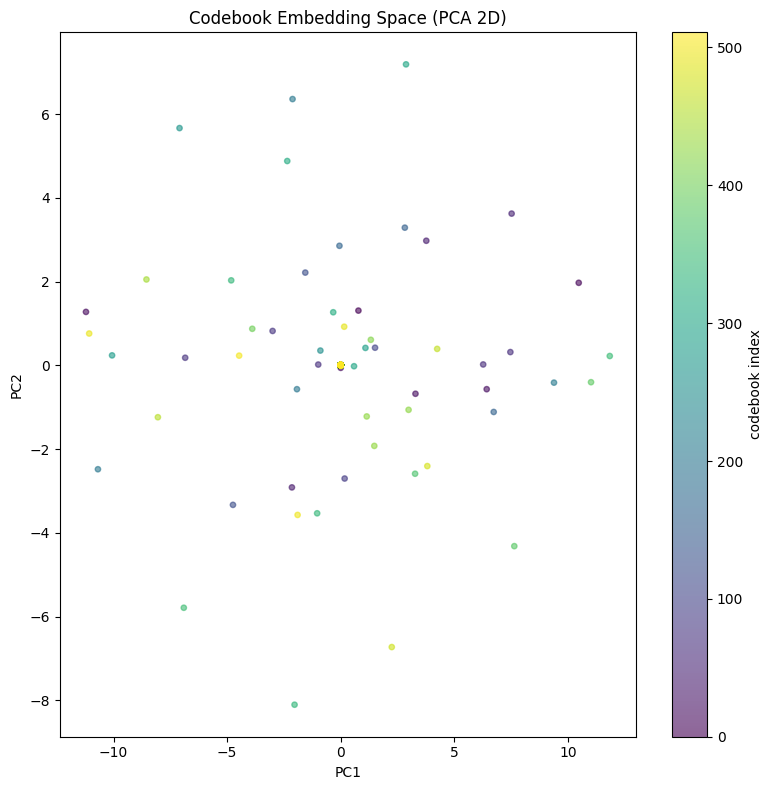

In [42]:
# color by index to see structure
plt.figure(figsize=(8, 8))
scatter = plt.scatter(reduced[:, 0], reduced[:, 1],
                      c=range(512), cmap='viridis', alpha=0.6, s=15)
plt.colorbar(scatter, label='codebook index')
plt.title('Codebook Embedding Space (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()